In [1]:
import pandas as pd
import sqlite3

# Connect to our new database
conn = sqlite3.connect("flights.db")

# Run a quick test query to pull the first 5 rows
query = "SELECT * FROM raw_flights LIMIT 5;"
df = pd.read_sql_query(query, conn)

# Display the clean table
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,None,None,None,None,None,None
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,None,None,None,None,None,None
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,None,None,None,None,None,None
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,None,None,None,None,None,None
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,None,None,None,None,None,None


In [2]:
query_routes = """
SELECT ORIGIN_AIRPORT, DESTINATION_AIRPORT, 
       COUNT(*) as TOTAL_FLIGHTS,
       AVG(DEPARTURE_DELAY) as AVG_DELAY
FROM raw_flights
GROUP BY ORIGIN_AIRPORT, DESTINATION_AIRPORT
HAVING TOTAL_FLIGHTS > 100
ORDER BY AVG_DELAY DESC
LIMIT 10;
"""
routes_df = pd.read_sql_query(query_routes, conn)
routes_df

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,TOTAL_FLIGHTS,AVG_DELAY
0,BOI,SFO,162,35.756579
1,BIS,DEN,116,34.773913
2,ORD,SLC,239,34.354701
3,ORD,OKC,124,33.651786
4,SJU,ORD,102,32.168317
5,CMH,ORD,318,31.093525
6,ORD,DEN,497,31.066946
7,ORD,IAD,166,30.383648
8,ORD,BWI,177,30.239264
9,JFK,ATL,166,30.127389


In [3]:
query_airlines = """
SELECT AIRLINE, 
       AVG(DEPARTURE_DELAY) as AVG_DEP_DELAY,
       SUM(CASE WHEN ARRIVAL_DELAY > 15 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as DELAY_RATE_PCT
FROM raw_flights
GROUP BY AIRLINE
ORDER BY AVG_DEP_DELAY DESC;
"""
airline_df = pd.read_sql_query(query_airlines, conn)
airline_df

,AIRLINE,AVG_DEP_DELAY,DELAY_RATE_PCT
0,F9,19.664576,31.669181
1,MQ,16.141276,30.097818
2,UA,14.169355,21.062804
3,NK,14.016792,26.823252
4,OO,12.458124,22.739528
5,B6,10.774558,22.109964
6,AA,10.643729,20.566560
7,EV,10.043026,21.108279
8,WN,9.631456,18.179251
9,VX,6.815032,15.131709


C:\Users\Madhu\AppData\Local\Temp\ipykernel_10268\397779158.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DAY_OF_WEEK', y='AVG_DELAY', data=time_df, palette='Blues_r')


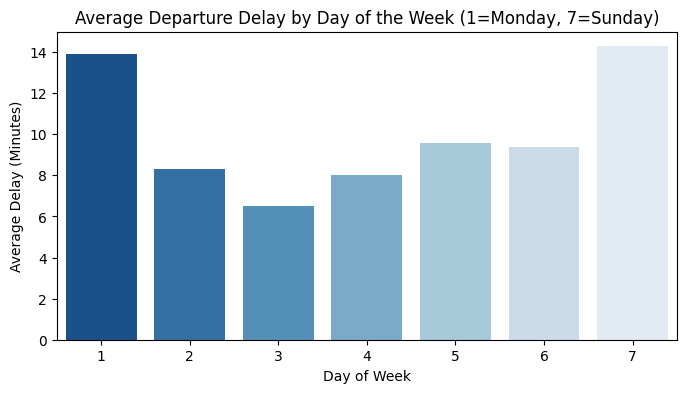

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

query_time = """
SELECT DAY_OF_WEEK, AVG(DEPARTURE_DELAY) as AVG_DELAY
FROM raw_flights
GROUP BY DAY_OF_WEEK;
"""
time_df = pd.read_sql_query(query_time, conn)

# Plotting the results cleanly
plt.figure(figsize=(8, 4))
sns.barplot(x='DAY_OF_WEEK', y='AVG_DELAY', data=time_df, palette='Blues_r')
plt.title('Average Departure Delay by Day of the Week (1=Monday, 7=Sunday)')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (Minutes)')
plt.show()

In [6]:
conn.close()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

print("Preparing data for Machine Learning...")

# 1. Re-open connection if you closed it
conn = sqlite3.connect("flights.db")

# 2. Extract specific columns for modeling
# We use a subset of 200,000 rows to ensure the model trains quickly on your machine
query_ml = """
SELECT MONTH, DAY_OF_WEEK, AIRLINE, DISTANCE, DEPARTURE_DELAY 
FROM raw_flights 
WHERE DEPARTURE_DELAY IS NOT NULL
LIMIT 200000;
"""
df_ml = pd.read_sql_query(query_ml, conn)

# 3. Define our target: 1 if flight is delayed > 15 mins, 0 if on time/early
df_ml['IS_DELAYED'] = (df_ml['DEPARTURE_DELAY'] > 15).astype(int)

# 4. Feature Engineering: Convert categorical 'AIRLINE' into numerical dummy columns
X = pd.get_dummies(df_ml[['MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'AIRLINE']], drop_first=True)
y = df_ml['IS_DELAYED']

print(f"Data ready. Features shape: {X.shape}, Target distribution:\n{y.value_counts(normalize=True)}")

Preparing data for Machine Learning...
Data ready. Features shape: (200000, 16), Target distribution:
IS_DELAYED
0    0.72186
1    0.27814
Name: proportion, dtype: float64


In [9]:
# 1. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Random Forest model (this might take 30-45 seconds)...")
# 2. Initialize and fit the model
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# 4. Display Results
print("\n--- MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Training Random Forest model (this might take 30-45 seconds)...

--- MODEL PERFORMANCE ---
Accuracy Score: 72.43%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.99      0.84     28900
           1       0.56      0.03      0.06     11100

    accuracy                           0.72     40000
   macro avg       0.64      0.51      0.45     40000
weighted avg       0.68      0.72      0.62     40000



C:\Users\Madhu\AppData\Local\Temp\ipykernel_10268\3217664303.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


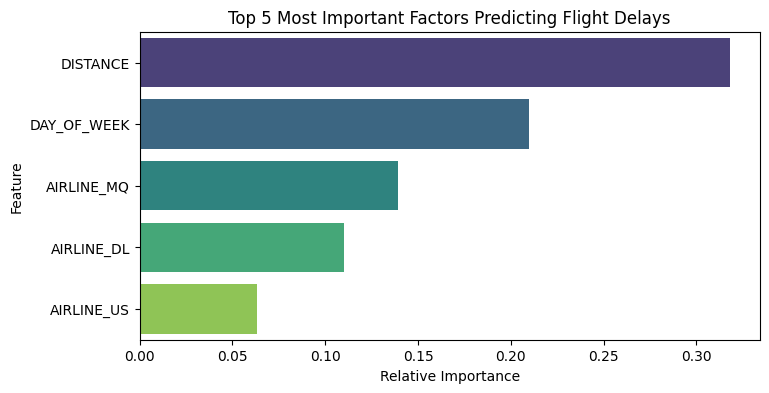

In [10]:
# Extract and sort feature importances
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Create a clean DataFrame of top 5 features
top_features = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices[:5]],
    'Importance': [importances[i] for i in indices[:5]]
})

# Plot Feature Importance
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 5 Most Important Factors Predicting Flight Delays')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

# Don't forget to close the connection permanently now!
conn.close()

In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("flights.db")

# 1. Route Summary Data
query_routes_summary = """
SELECT ORIGIN_AIRPORT, DESTINATION_AIRPORT, 
       COUNT(*) as TOTAL_FLIGHTS,
       AVG(DEPARTURE_DELAY) as AVG_DEP_DELAY,
       AVG(ARRIVAL_DELAY) as AVG_ARR_DELAY
FROM raw_flights
GROUP BY ORIGIN_AIRPORT, DESTINATION_AIRPORT;
"""
routes_summary = pd.read_sql_query(query_routes_summary, conn)
routes_summary.to_csv("dashboard_routes.csv", index=False)

# 2. Airline & Time Performance Summary Data
query_perf_summary = """
SELECT MONTH, DAY_OF_WEEK, AIRLINE,
       COUNT(*) as TOTAL_FLIGHTS,
       AVG(DEPARTURE_DELAY) as AVG_DEP_DELAY,
       SUM(CASE WHEN ARRIVAL_DELAY > 15 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as DELAY_RATE_PCT
FROM raw_flights
GROUP BY MONTH, DAY_OF_WEEK, AIRLINE;
"""
perf_summary = pd.read_sql_query(query_perf_summary, conn)
perf_summary.to_csv("dashboard_performance.csv", index=False)

conn.close()
print("Dashboard summary CSVs successfully created!")

Dashboard summary CSVs successfully created!
